# DataPre-Processing & Feature Selection

## Importing Lib

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

## Data Loading 

In [3]:
df=pd.read_csv("male_players_20.csv")
pd.set_option("display.max_columns",None)


In [4]:
df.replace('[!@#\?]','',regex=True,inplace=True)

In [5]:
columns = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm',
           'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb']
df[columns]

for colmun in columns:
    df[colmun] = df[colmun].str.split('+',expand=True)[0]

## Data Preprocessing

### 1. Handle Missing Values

In [6]:
pd.set_option('display.max_rows',None)
df.isnull().sum()

sofifa_id                         0
player_url                        0
short_name                        0
long_name                         0
age                               0
dob                               0
height_cm                         0
weight_kg                         0
nationality                       0
club                              0
overall                           0
potential                         0
value_eur                         0
wage_eur                          0
player_positions                  0
preferred_foot                    0
international_reputation          0
weak_foot                         0
skill_moves                       0
work_rate                         0
body_type                         0
real_face                         0
release_clause_eur             1298
player_tags                   16779
team_position                   240
team_jersey_number              240
loaned_from                   17230
joined                      

In [7]:
columns_to_impute = ['release_clause_eur','contract_valid_until', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

for column in columns_to_impute:
    median_value = df[column].median()
    df[column].fillna(median_value, inplace=True)

In [8]:
for column in columns_to_impute:
    missing_count = df[column].isnull().sum()
    print(f"{column}: {missing_count}")

release_clause_eur: 0
contract_valid_until: 0
pace: 0
shooting: 0
passing: 0
dribbling: 0
defending: 0
physic: 0


In [9]:
df["team_position"].mode()
df.loc[df["team_position"].isnull()==True,"team_position"]="SUB"

In [10]:
df["team_position"].value_counts()

team_position
SUB    8060
RES    2958
GK      662
RCB     660
LCB     660
RB      560
LB      560
ST      458
RCM     411
LCM     411
RM      399
LM      398
CAM     311
RDM     244
LDM     242
RS      195
LS      195
CDM     181
LW      162
RW      161
CB      100
CM       76
RWB      58
LWB      58
RAM      23
LAM      23
RF       19
LF       19
CF       14
Name: count, dtype: int64

In [11]:
df.loc[df["team_position"]=="CF","team_position"]=0
df.loc[df["team_position"]=="LF","team_position"]=1
df.loc[df["team_position"]=="RF","team_position"]=2
df.loc[df["team_position"]=="LAM","team_position"]=3
df.loc[df["team_position"]=="RAM","team_position"]=4
df.loc[df["team_position"]=="LWB","team_position"]=5
df.loc[df["team_position"]=="RWB","team_position"]=6
df.loc[df["team_position"]=="CM","team_position"]=7
df.loc[df["team_position"]=="CB","team_position"]=8
df.loc[df["team_position"]=="RW","team_position"]=9
df.loc[df["team_position"]=="LW","team_position"]=10
df.loc[df["team_position"]=="CDM","team_position"]=11
df.loc[df["team_position"]=="LS","team_position"]=12
df.loc[df["team_position"]=="RS","team_position"]=13
df.loc[df["team_position"]=="LDM","team_position"]=14
df.loc[df["team_position"]=="RDM","team_position"]=15
df.loc[df["team_position"]=="CAM","team_position"]=16
df.loc[df["team_position"]=="LM","team_position"]=17
df.loc[df["team_position"]=="RM","team_position"]=18
df.loc[df["team_position"]=="LCM","team_position"]=19
df.loc[df["team_position"]=="RCM","team_position"]=20
df.loc[df["team_position"]=="ST","team_position"]=21
df.loc[df["team_position"]=="LB","team_position"]=22
df.loc[df["team_position"]=="RB","team_position"]=23
df.loc[df["team_position"]=="LCB","team_position"]=24
df.loc[df["team_position"]=="RCB","team_position"]=25
df.loc[df["team_position"]=="GK","team_position"]=26
df.loc[df["team_position"]=="RES","team_position"]=27
df.loc[df["team_position"]=="SUB","team_position"]=28

### 2. Handle Outliers

In [12]:
num_df=df.select_dtypes(include=["int64","float64"])
num_df.columns

Index(['sofifa_id', 'age', 'height_cm', 'weight_kg', 'overall', 'potential',
       'value_eur', 'wage_eur', 'international_reputation', 'weak_foot',
       'skill_moves', 'release_clause_eur', 'team_jersey_number',
       'contract_valid_until', 'nation_jersey_number', 'pace', 'shooting',
       'passing', 'dribbling', 'defending', 'physic', 'gk_diving',
       'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed',
       'gk_positioning', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'power_shot_power',
       'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
       'mentality_aggression', 'mentality_interceptions',
       'mentality_positionin

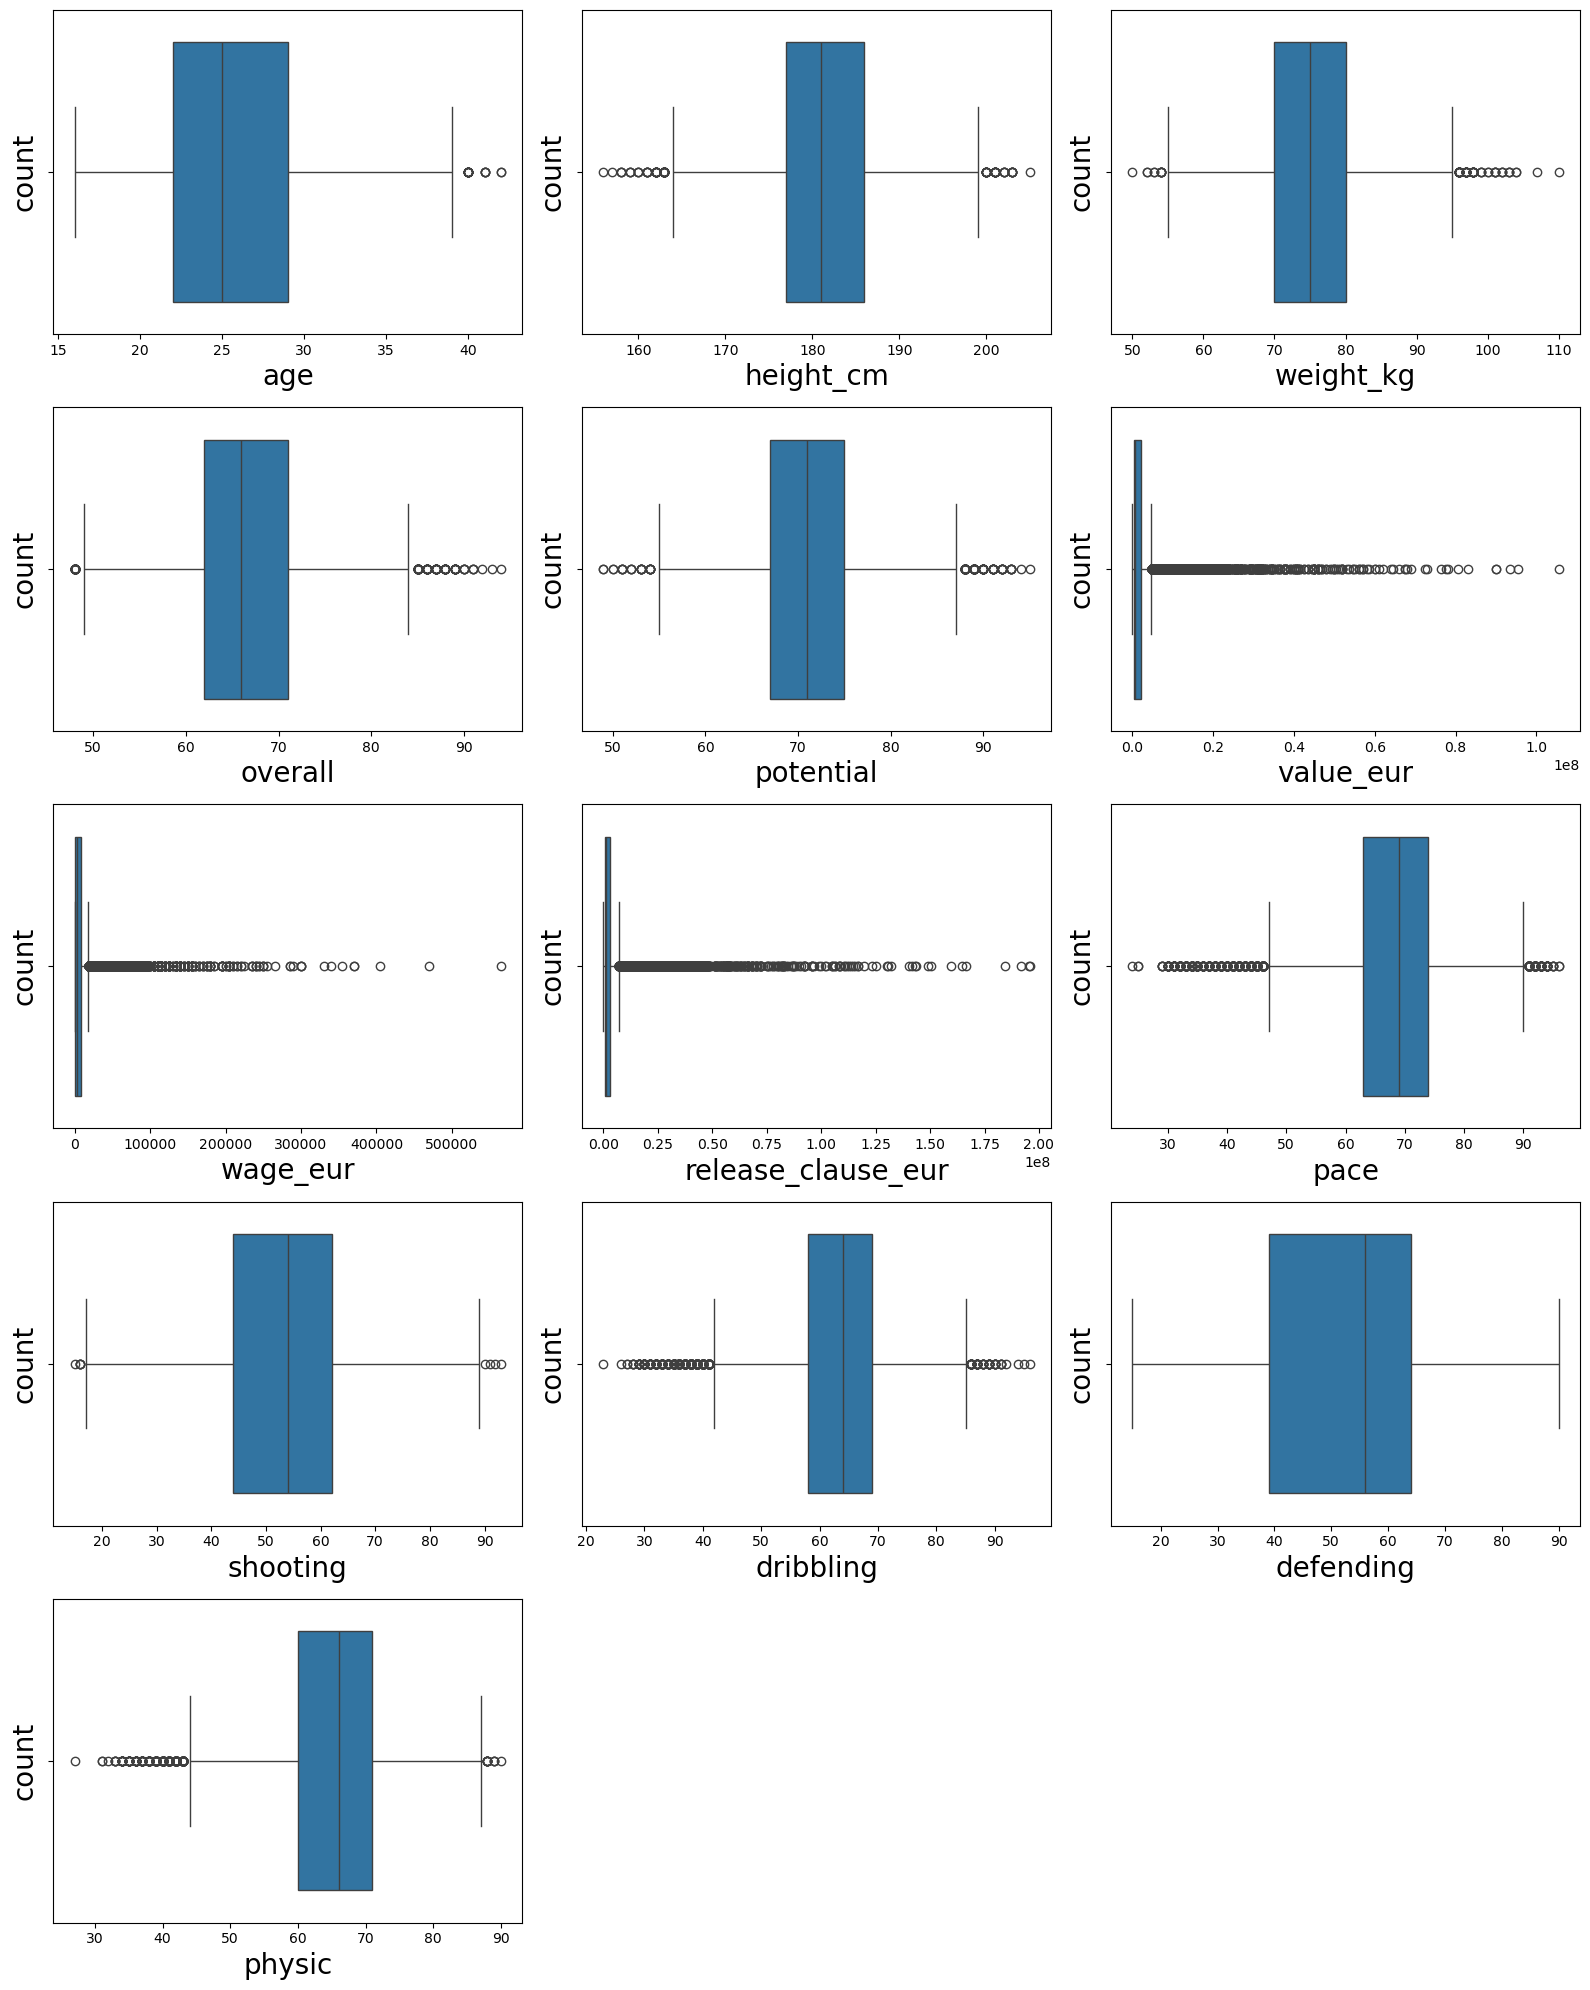

In [13]:
outlier_check = ['age','height_cm','weight_kg','overall','potential','value_eur','wage_eur','release_clause_eur','pace',
           'shooting','dribbling','defending','physic']

plt.figure(figsize=(16,20),facecolor="white")
plotnumber=1

for column in outlier_check:
    if plotnumber<=len(num_df):
        plt.subplot(5,3,plotnumber)
        sns.boxplot(x=df[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel("count",fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [14]:
# Age
Q1=df["age"].quantile(0.25)
Q3=df["age"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [15]:
df.loc[df["age"]>upper_limit]
len(df.loc[df["age"]>upper_limit])/len(df)
df.loc[df["age"]>upper_limit,"age"]=df["age"].median()

In [16]:
df.loc[df["age"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb


In [17]:
# Height
lower_limit=df["height_cm"].mean()-3*df["height_cm"].std()
upper_limit=df["height_cm"].mean()+3*df["height_cm"].std()

In [18]:
df.loc[df["height_cm"]>upper_limit]
len(df.loc[df["height_cm"]>upper_limit])/len(df)
df.loc[df["height_cm"]>upper_limit,"height_cm"]=df["height_cm"].median()

In [19]:
df.loc[df["height_cm"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
1352,221634,https://sofifa.com/player/221634/luciano-acost...,L. Acosta,Luciano Federico Acosta,25,1994-05-31,161,61,Argentina,DC United,76,80,10000000,9000,"CAM, LM",Right,1,3,5,High/Medium,Normal,Yes,15800000.0,NaN,17,10.0,NaN,2016-11-16,2019.0,NaN,NaN,81.0,67.0,71.0,80.0,46.0,61.0,NaN,NaN,NaN,NaN,NaN,NaN,"Selfish, Finesse Shot, Crowd Favourite",61,67,53,77,67,80,74,62,70,77,87,76,88,74,90,71,57,75,51,67,69,44,72,73,54,73,47,47,33,13,9,6,12,10,70,70,70,74,74,74,74,74,75,75,75,74,71,71,71,74,61,61,61,61,61,58,52,52,52,58
1496,183895,https://sofifa.com/player/183895/maxi-moralez/...,M. Moralez,Maximiliano Nicol Moralez,32,1987-02-27,158,56,Argentina,New York City FC,76,76,6000000,9000,"CAM, CM",Right,2,4,4,High/High,Normal,Yes,9000000.0,NaN,19,10.0,NaN,2017-02-15,2022.0,NaN,NaN,73.0,71.0,74.0,77.0,52.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Finesse Shot, Crowd Favourite",74,72,56,74,70,77,76,70,73,76,82,65,81,74,77,69,31,76,33,70,65,45,74,77,74,76,48,58,51,6,5,14,14,9,69,69,69,74,73,73,73,74,74,74,74,74,72,72,72,74,65,62,62,62,65,62,53,53,53,62
1923,170719,https://sofifa.com/player/170719/diego-buonano...,D. Buonanotte,Diego Mario Buonanotte Rende,31,1988-04-19,161,57,Argentina,Universidad Católica,75,75,6000000,13000,CAM,Left,2,4,4,Medium/Low,Lean,No,8400000.0,Acrobat,28,18.0,NaN,2016-07-20,2020.0,NaN,NaN,84.0,67.0,72.0,79.0,30.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,"Selfish, Finesse Shot, Speed Dribbler (CPU AI ...",72,62,36,71,61,77,78,76,70,77,82,85,90,70,94,69,61,60,29,77,30,25,69,72,71,68,35,31,18,15,16,16,9,13,65,65,65,74,72,72,72,74,73,73,73,73,67,67,67,73,54,49,49,49,54,50,37,37,37,50
3159,199940,https://sofifa.com/player/199940/juan-ezequiel...,J. Cuevas,Juan Ezequiel Cuevas,31,1988-06-04,161,63,Argentina,CD Everton de Viña del Mar,73,73,3500000,5000,"RW, LW, LM",Left,1,3,3,High/Medium,Normal,No,4700000.0,NaN,9,10.0,NaN,2017-06-27,2020.0,NaN,NaN,85.0,64.0,71.0,76.0,44.0,63.0,NaN,NaN,NaN,NaN,NaN,NaN,"Finesse Shot, Crowd Favourite",72,65,59,74,59,74,67,70,62,74,88,82,84,67,91,64,78,71,57,61,63,40,71,72,71,58,34,51,48,15,13,8,13,16,68,68,68,73,71,71,71,73,72,72,72,73,67,67,67,73,62,58,58,58,62,60,53,53,53,60
3898,202184,https://sofifa.com/player/202184/joao-plata/20...,J. Plata,João Jimmy Plata Cotera,27,1992-03-01,157,71,Ecuador,Real Salt Lake,72,72,3300000,7000,"LW, LM",Right,1,2,3,High/Medium,Normal,No,4900000.0,Acrobat,28,10.0,NaN,2013-01-01,2023.0,NaN,NaN,85.0,67.0,69.0,74.0,34.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,"Argues with Officials, Crowd Favourite",65,65,62,69,64,71,70,69,64,70,89,81,94,74,93,74,63,70,58,64,52,29,69,74,69,70,34,29,27,11,15,9,13,13,69,69,69,72,71,71,71,72,71,71,71,71,65,65,65,71,55,52,52,52,55,52,45,45,45,52
3946,214327,https://sofifa.com/player/214327/vladimir-h

In [20]:
# Weight
lower_limit=df["weight_kg"].mean()-3*df["weight_kg"].std()
upper_limit=df["weight_kg"].mean()+3*df["weight_kg"].std()

In [21]:
df.loc[df["weight_kg"]>upper_limit]
len(df.loc[df["weight_kg"]>upper_limit])/len(df)
df.loc[df["weight_kg"]>upper_limit,"weight_kg"]=df["weight_kg"].median()

In [22]:
df.loc[df["weight_kg"]<lower_limit]
len(df.loc[df["weight_kg"]<lower_limit])/len(df)
df.loc[df["weight_kg"]<lower_limit,"weight_kg"]=df["weight_kg"].median()

In [23]:
# Overall
lower_limit=df["overall"].mean()-3*df["overall"].std()
upper_limit=df["overall"].mean()+3*df["overall"].std()

In [24]:
df.loc[df["overall"]>upper_limit]
len(df.loc[df["overall"]>upper_limit])/len(df)
df.loc[df["overall"]>upper_limit,"overall"]=df["overall"].median()

In [25]:
df.loc[df["overall"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb


In [26]:
# Potential
lower_limit=df["potential"].mean()-3*df["potential"].std()
upper_limit=df["potential"].mean()+3*df["potential"].std()

In [27]:
df.loc[df["potential"]>upper_limit]
len(df.loc[df["potential"]>upper_limit])/len(df)
df.loc[df["potential"]>upper_limit,"potential"]=df["potential"].median()

In [28]:
df.loc[df["potential"]<lower_limit]
len(df.loc[df["potential"]<lower_limit])/len(df)
df.loc[df["potential"]<lower_limit,"potential"]=df["potential"].median()

In [29]:
# Value_Eur
Q1=df["value_eur"].quantile(0.25)
Q3=df["value_eur"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [30]:
df.loc[df["value_eur"]>upper_limit,"value_eur"]=df["value_eur"].median()

In [31]:
# Wage_Eur
Q1=df["wage_eur"].quantile(0.25)
Q3=df["wage_eur"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [32]:
df.loc[df["wage_eur"]>upper_limit,"wage_eur"]=df["wage_eur"].median()

In [33]:
# Release_Clause_Eur
Q1=df["release_clause_eur"].quantile(0.25)
Q3=df["release_clause_eur"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [34]:
df.loc[df["release_clause_eur"]>upper_limit,"release_clause_eur"]=df["release_clause_eur"].median()

In [35]:
# Pace
Q1=df["pace"].quantile(0.25)
Q3=df["pace"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [36]:
df.loc[df["pace"]>upper_limit,"pace"]=df["pace"].median()

In [37]:
df.loc[df["pace"]<lower_limit,"pace"]=df["pace"].median()

In [38]:
# Shooting
Q1=df["shooting"].quantile(0.25)
Q3=df["shooting"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [39]:
df.loc[df["shooting"]>upper_limit,"shooting"]=df["shooting"].median()

In [40]:
df.loc[df["shooting"]<lower_limit,"shooting"]=df["shooting"].median()

In [41]:
# Dribbling
Q1=df["dribbling"].quantile(0.25)
Q3=df["dribbling"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [42]:
df.loc[df["dribbling"]>upper_limit,"dribbling"]=df["dribbling"].median()

In [43]:
df.loc[df["dribbling"]<lower_limit,"dribbling"]=df["dribbling"].median()

In [44]:
# Physic
Q1=df["physic"].quantile(0.25)
Q3=df["physic"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [45]:
df.loc[df["physic"]>upper_limit,"physic"]=df["physic"].median()

In [46]:
df.loc[df["physic"]<lower_limit,"physic"]=df["physic"].median()

### 3. Scaling

In [47]:
scaler = MinMaxScaler() # Object Creation
df[['age','height_cm','weight_kg','overall','potential','value_eur','wage_eur','release_clause_eur','pace','shooting','passing','dribbling','defending','physic','attacking_crossing','attacking_crossing',
    'attacking_finishing','attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling','skill_curve','skill_fk_accuracy','skill_fk_accuracy','skill_long_passing',
    'skill_ball_control','skill_ball_control','movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance','power_shot_power','power_jumping',
    'power_stamina','power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision','mentality_penalties','mentality_composure','defending_marking',
    'defending_standing_tackle','defending_sliding_tackle','goalkeeping_diving','goalkeeping_handling','goalkeeping_kicking','goalkeeping_positioning',
    'goalkeeping_reflexes']]=scaler.fit_transform(df[['age','height_cm','weight_kg','overall','potential','value_eur','wage_eur','release_clause_eur','pace','shooting','passing','dribbling','defending',
                'physic','attacking_crossing','attacking_crossing','attacking_finishing','attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling','skill_curve','skill_fk_accuracy',
                'skill_fk_accuracy','skill_long_passing','skill_ball_control','skill_ball_control','movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance',
                'power_shot_power','power_jumping','power_stamina','power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision','mentality_penalties',
                'mentality_composure','defending_marking','defending_standing_tackle','defending_sliding_tackle','goalkeeping_diving','goalkeeping_handling','goalkeeping_kicking','goalkeeping_positioning','goalkeeping_reflexes']])

## Feature Selection

In [48]:
# Drop column
df.drop(['sofifa_id','player_url','short_name','long_name','dob','nationality','club','player_positions','body_type',
          'real_face','player_tags','team_jersey_number','loaned_from','joined','contract_valid_until','nation_position',
          'nation_jersey_number','gk_diving','gk_handling','gk_kicking','gk_reflexes','gk_speed','gk_positioning',
          'player_traits','ls','st','rs','lw','cf','rf','rw','lam','cam','ram','lm','lcm','cm','rcm','rm','lwb','ldm',
          'cdm','rdm','rwb','lb','lcb','cb','rcb','rb','lf','work_rate'],axis=1,inplace=True)

In [49]:
df.head()

,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,preferred_foot,international_reputation,weak_foot,skill_moves,release_clause_eur,team_position,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,0.695652,0.311111,0.414634,0.461538,0.485714,0.148936,0.166667,Left,5,4,4,0.16749,9,0.930233,0.513889,1.000000,0.511628,0.320000,0.511628,0.943182,1.000000,0.738636,1.000000,0.977011,1.000000,0.988636,1.000000,1.000000,1.000000,0.929412,0.858824,0.964706,0.986667,0.976471,0.888889,0.644737,0.741176,0.623377,1.000000,0.453488,0.415730,0.989247,1.000000,0.800000,1.000000,0.344086,0.367816,0.264368,0.056180,0.109890,0.152174,0.144444,0.076923
1,0.782609,0.688889,0.682927,0.461538,0.485714,0.148936,0.166667,Right,5,4,5,0.16749,10,1.000000,0.513889,0.852941,0.511628,0.266667,0.790698,0.897727,0.989247,0.954545,0.894118,0.965517,0.913978,0.852273,0.800000,0.821429,0.956044,0.905882,0.941176,0.894118,1.000000,0.694118,1.000000,1.000000,0.858824,0.753247,0.988889,0.627907,0.292135,1.000000,0.858824,0.917647,0.988095,0.290323,0.310345,0.241379,0.067416,0.109890,0.152174,0.144444,0.109890
2,0.478261,0.422222,0.317073,0.461538,0.485714,0.148936,0.166667,Right,5,5,5,0.16749,16,0.511628,0.944444,0.926471,0.511628,0.226667,0.325581,0.931818,0.913978,0.647727,0.941176,0.965517,0.989247,0.931818,0.922222,0.869048,0.989011,0.964706,0.917647,1.000000,0.946667,0.847059,0.814815,0.552632,0.811765,0.376623,0.888889,0.488372,0.370787,0.913978,0.952941,0.976471,0.976190,0.279570,0.241379,0.298851,0.089888,0.087912,0.152174,0.155556,0.109890
3,0.434783,0.711111,0.780488,0.461538,0.485714,0.148936,0.166667,Right,3,3,1,0.16749,26,0.511628,0.513889,0.500000,0.511628,0.546667,0.511628,0.090909,0.096774,0.113636,0.423529,0.114943,0.086022,0.079545,0.111111,0.380952,0.274725,0.364706,0.576471,0.658824,0.893333,0.435294,0.555556,0.776316,0.341176,0.753247,0.088889,0.290698,0.179775,0.096774,0.658824,0.047059,0.666667,0.279570,0.080460,0.172414,0.966292,1.000000,0.836957,0.988889,0.967033
4,0.521739,0.422222,0.463415,0.461538,0.485714,0.148936,0.166667,Right,4,4,4,0.16749,10,0.511628,0.916667,0.911765,0.511628,0.266667,0.511628,0.863636,0.881720,0.636364,0.964706,0.919540,0.978495,0.875000,0.833333,0.892857,0.978022,0.964706,0.905882,0.988235,0.920000,0.964706,0.839506,0.486842,0.847059,0.558442,0.844444,0.523256,0.426966,0.913978,0.941176,0.952941,0.940476,0.354839,0.252874,0.218391,0.112360,0.120879,0.054348,0.077778,0.076923


In [50]:
df.corr(numeric_only=True)


,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,skill_moves,release_clause_eur,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
age,1.000000,0.081527,0.235452,0.465864,-0.263490,0.142250,0.202944,0.256229,0.073575,0.048368,0.114721,-0.066865,0.223729,0.307110,0.142074,0.245395,0.377186,0.131588,0.081417,0.152861,0.138975,0.145703,0.020202,0.144368,0.192785,0.186298,0.091421,-0.148685,-0.139604,-0.019292,0.464164,-0.087434,0.263680,0.186644,0.121439,0.341862,0.164404,0.262186,0.198412,0.089557,0.196567,0.143113,0.370763,0.159595,0.119605,0.104207,0.106934,0.109127,0.108808,0.117147,0.108411
height_cm,0.081527,1.000000,0.761361,0.039475,-0.003532,-0.010171,-0.004956,0.038110,-0.174041,-0.428975,-0.014760,-0.324393,-0.167949,-0.252587,-0.303933,0.227760,0.414050,-0.496801,-0.375036,0.012354,-0.369628,-0.349913,-0.498546,-0.446474,-0.409050,-0.333459,-0.423163,-0.556810,-0.473436,-0.631788,-0.018360,-0.788462,-0.173504,-0.037997,-0.290027,0.535692,-0.382987,-0.043459,-0.051660,-0.443902,-0.370690,-0.334462,-0.158472,-0.075590,-0.066914,-0.075484,0.365417,0.365151,0.362819,0.364922,0.365307
weight_kg,0.235452,0.761361,1.000000,0.152552,-0.015152,0.037636,0.042738,0.089637,-0.126266,-0.347653,0.027400,-0.271477,-0.073811,-0.157084,-0.217049,0.224683,0.488787,-0.396813,-0.288253,0.045315,-0.285739,-0.257023,-0.410770,-0.345002,-0.306692,-0.256770,-0.334986,-0.487599,-0.416543,-0.538547,0.089653,-0.662445,-0.055130,0.036346,-0.213267,0.611305,-0.275824,0.033739,-0.024492,-0.351477,-0.279554,-0.241954,-0.053030,-0.045041,-0.048658,-0.060439,0.334485,0.336372,0.332871,0.337006,0.335853
overall,0.465864,0.039475,0.152552,1.000000,0.627097,0.493308,0.436723,0.430952,0.227001,0.400069,0.459720,0.185539,0.454217,0.627423,0.528645,0.303956,0.450812,0.389242,0.340176,0.347043,0.500667,0.391418,0.370264,0.414349,0.387573,0.484486,0.455662,0.184829,0.197482,0.251510,0.853624,0.102933,0.564405,0.265493,0.370850,0.361494,0.424508,0.402248,0.318308,0.354726,0.503855,0.344797,0.713357,0.305642,0.253199,0.223372,-0.017936,-0.018481,-0.022103,-0.011359,-0.017602
potential,-0.263490,-0.003532,-0.015152,0.627097,1.000000,0.374326,0.279989,0.313786,0.164145,0.323237,0.379089,0.183212,0.273638,0.384732,0.399420,0.131127,0.135261,0.237055,0.240794,0.203838,0.359757,0.251863,0.303181,0.270259,0.219015,0.317463,0.341996,0.221666,0.219620,0.212508,0.502262,0.134068,0.342892,0.105419,0.191977,0.073729,0.260427,0.177259,0.150817,0.239470,0.340580,0.222125,0.433044,0.166821,0.144510,0.128949,-0.052782,-0.053588,-0.058824,-0.052217,-0.054221
value_eur,0.142250,-0.010171,0.037636,0.493308,0.374326,1.000000,0.480580,0.054531,0.113849,0.256394,0.749162,0.125114,0.241702,0.303777,0.281966,0.099410,0.208655,0.226093,0.216786,0.208920,0.288714,0.231864,0.239487,0.240825,0.216507,0.262515,0.278310,0.151919,0.158285,0.174352,0.411360,0.080072,0.314812,0.133120,0.227789,0.171739,0.254870,0.203334,0.143386,0.225551,0.268413,0.211691,0.364896,0.146130,0.117271,0.103516,-0.065401,-0.064428,-0.066344,-0.061441,-0.064134
wage_eur,0.202944,-0.004956,0.042738,0.436723,0.279989,0.480580,1.000000,0.044020,0.101288,0.215549,0.450323,0.084246,0.221495,0.276547,0.249382,0.099257,0.193792,0.196385,0.185069,0.179051,0.235609,0.201558,0.195895,0.211355,0.193630,0.223650,0.228357,0.10320

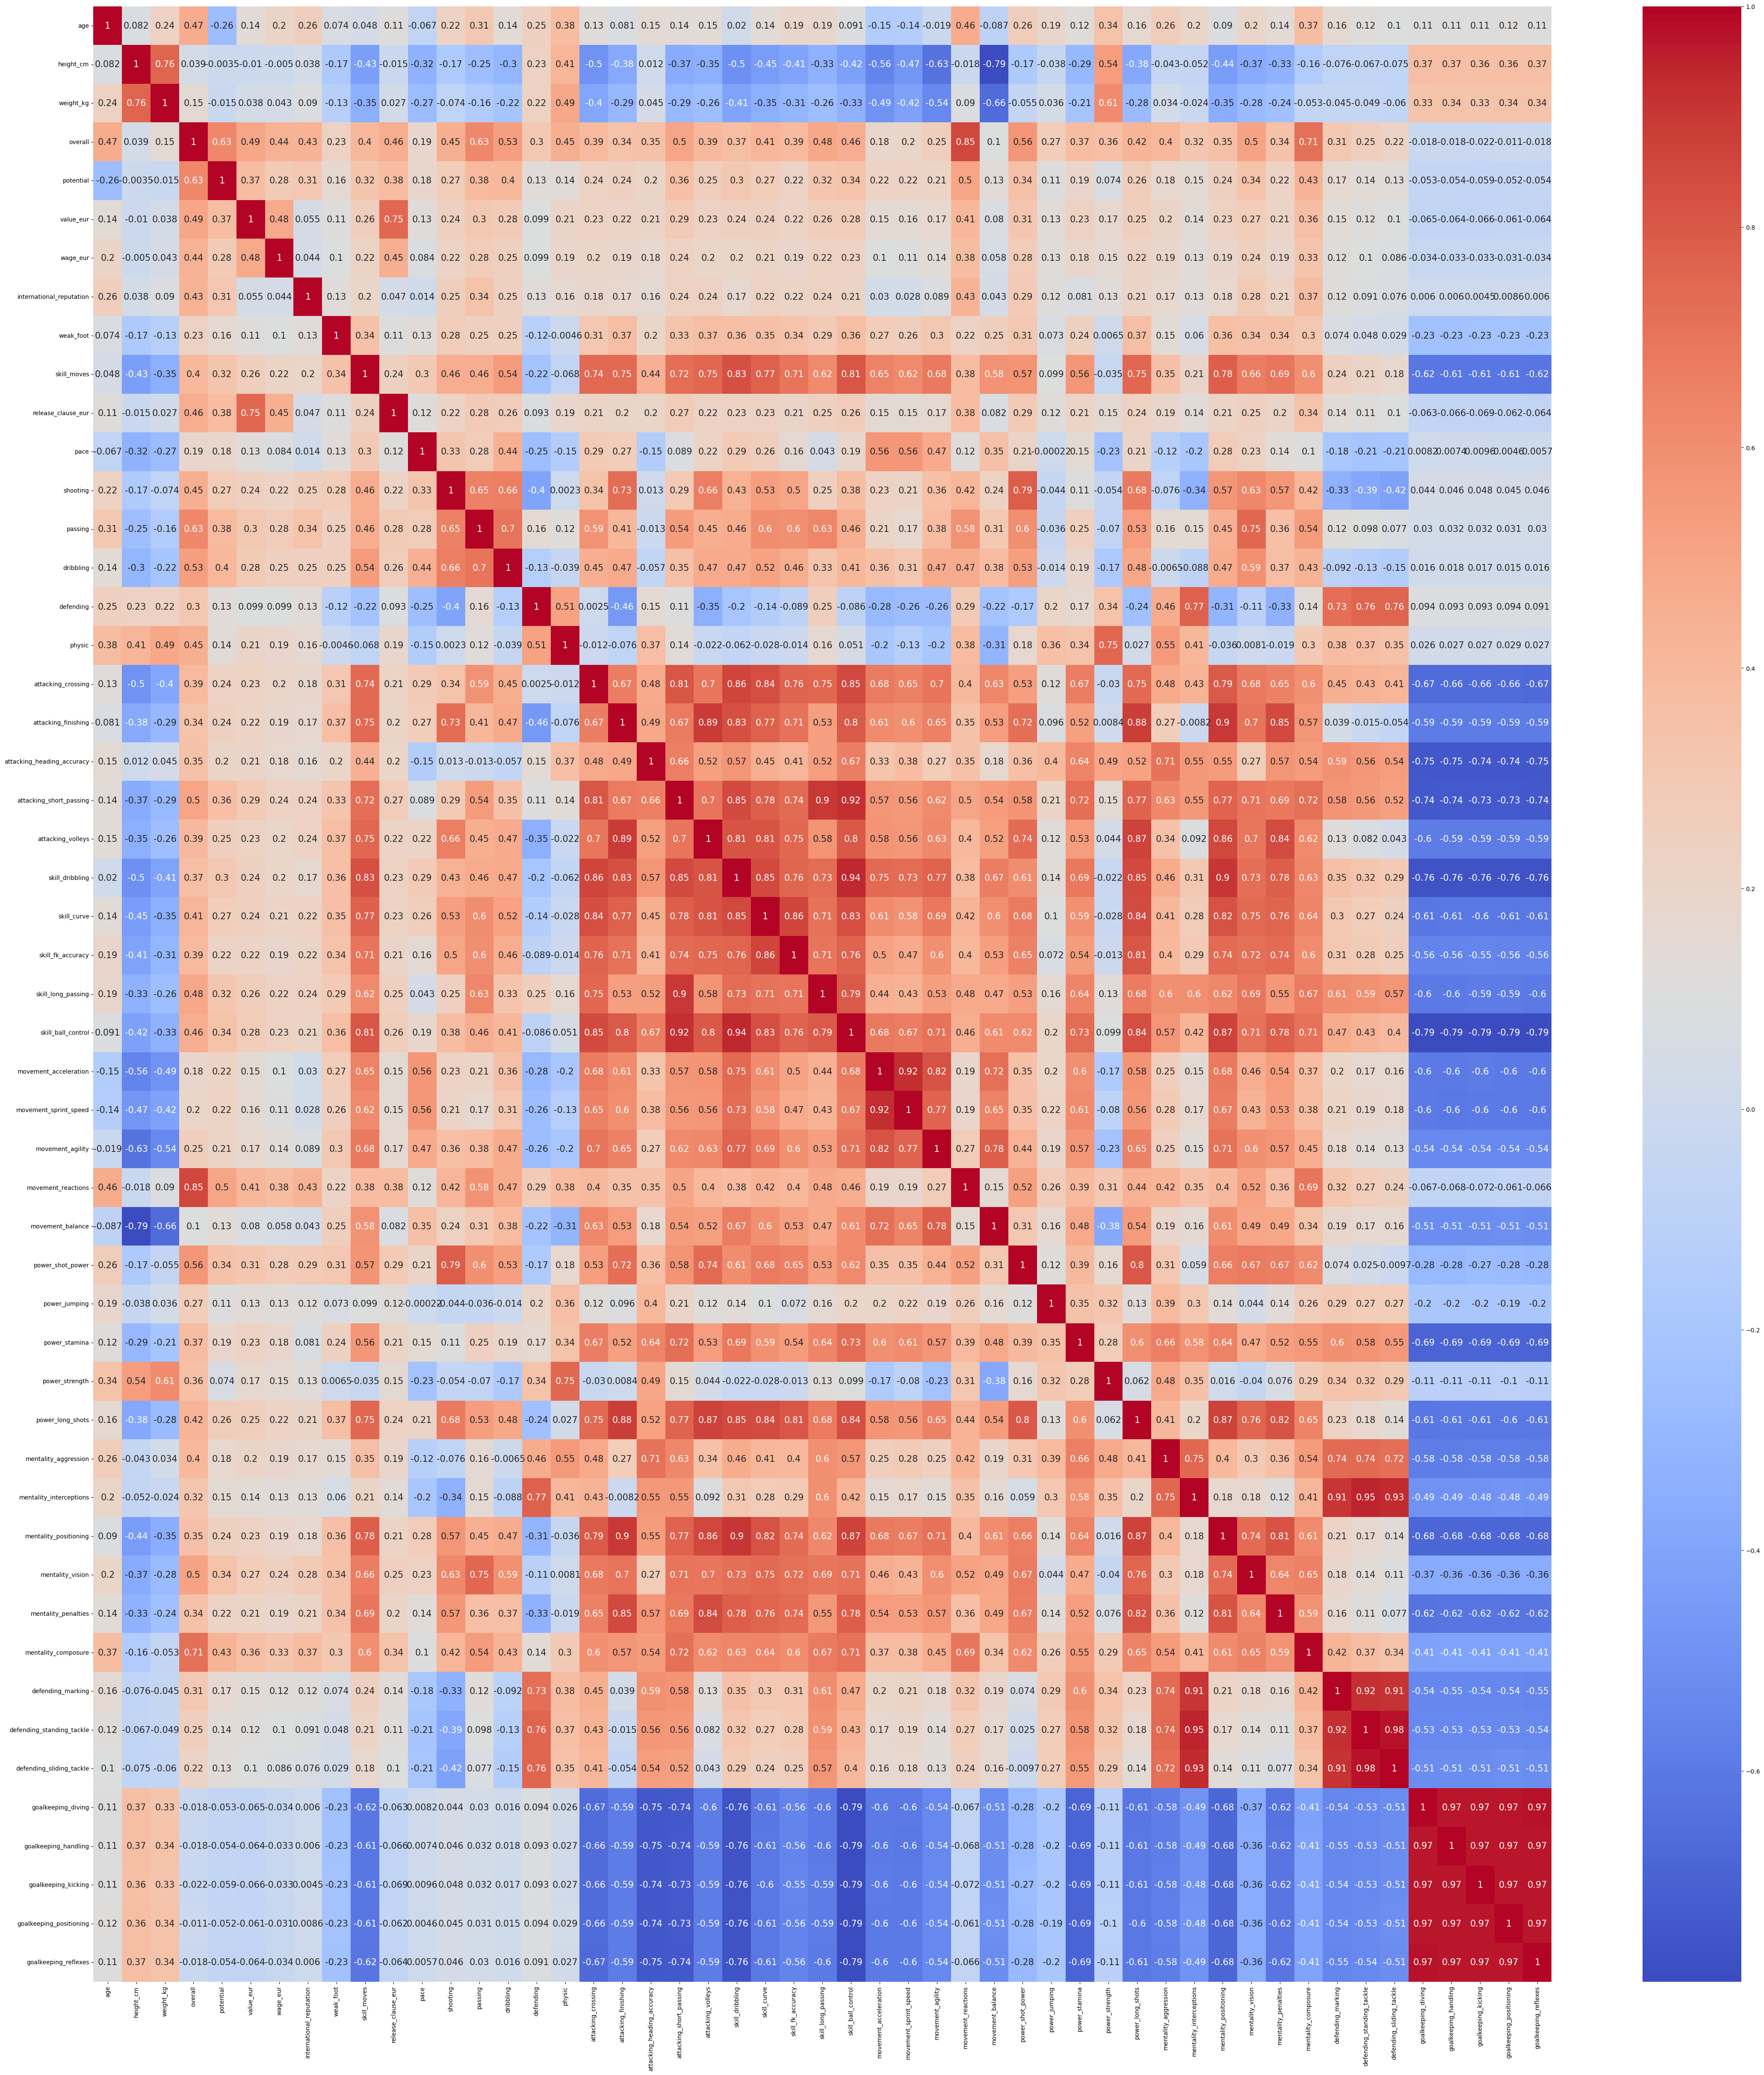

In [51]:
plt.figure(figsize=(55,60))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",annot_kws={"size":15})
plt.show()

In [52]:
pd.set_option('display.max_rows',None)
corrmat = df.corr(numeric_only=True)
corrmat = corrmat.abs().unstack()
corrmat = corrmat.sort_values(ascending=False)
corrmat = corrmat [corrmat >= 0.9]
corrmat = corrmat [corrmat < 1]
corrmat = pd.DataFrame(corrmat).reset_index()
corrmat.columns = ['feature1','feature2','corr']
corrmat

,feature1,feature2,corr
0,defending_standing_tackle,defending_sliding_tackle,0.975808
1,defending_sliding_tackle,defending_standing_tackle,0.975808
2,goalkeeping_diving,goalkeeping_reflexes,0.973922
3,goalkeeping_reflexes,goalkeeping_diving,0.973922
4,goalkeeping_diving,goalkeeping_handling,0.971330
5,goalkeeping_handling,goalkeeping_diving,0.971330
6,goalkeeping_reflexes,goalkeeping_handling,0.971244
7,goalkeeping_handling,goalkeeping_reflexes,0.971244
8,goalkeeping_positioning,goalkeeping_diving,0.971218
9,goalkeeping_diving,goalkeeping_positioning,0.971218


In [53]:
df.drop(['defending_standing_tackle','goalkeeping_diving','goalkeeping_handling',
           'goalkeeping_positioning','goalkeeping_reflexes','mentality_interceptions','skill_ball_control',
           'movement_sprint_speed','defending_marking','mentality_positioning','attacking_short_passing'],axis=1,inplace=True)

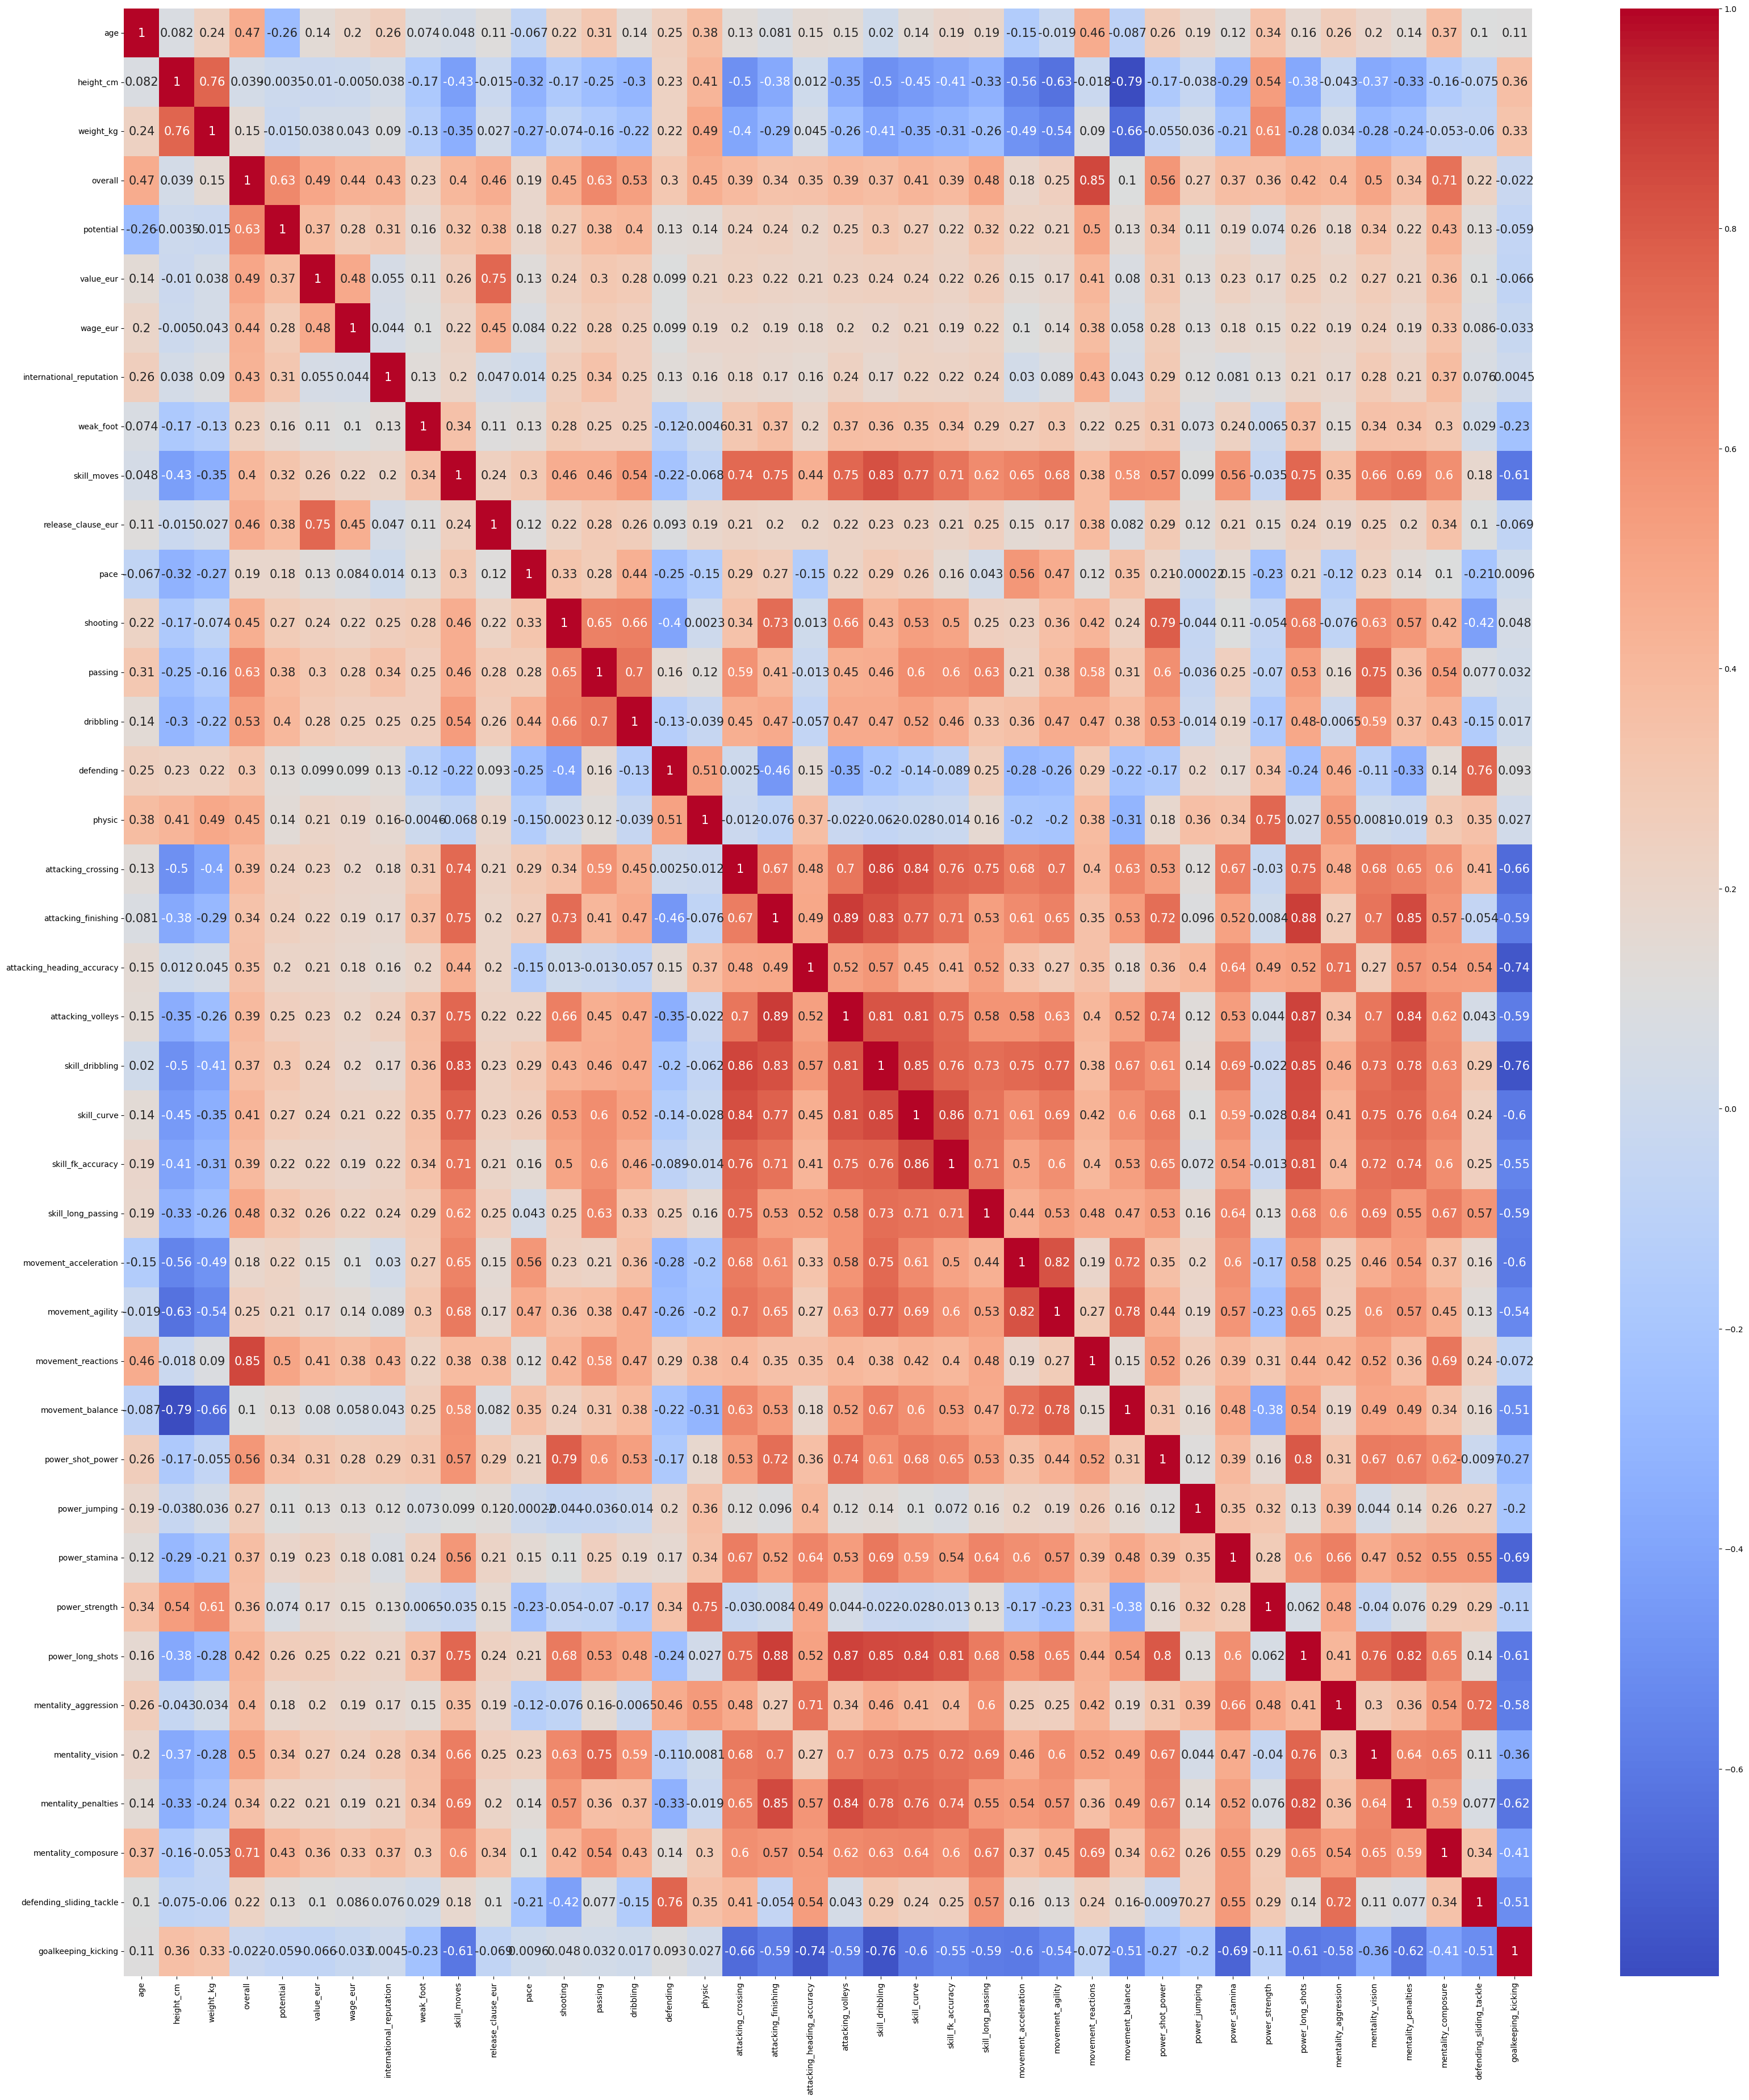

In [54]:
plt.figure(figsize=(40,45))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",annot_kws={"size":15})
plt.show()

In [55]:
df.to_csv('fifa20PreprocessData.csv', index=False)

In [56]:
preprocess_df = pd.read_csv("fifa20PreprocessData.csv")
preprocess_df.head(1)

,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,preferred_foot,international_reputation,weak_foot,skill_moves,release_clause_eur,team_position,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,movement_acceleration,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_vision,mentality_penalties,mentality_composure,defending_sliding_tackle,goalkeeping_kicking
0,0.695652,0.311111,0.414634,0.461538,0.485714,0.148936,0.166667,Left,5,4,4,0.16749,9,0.930233,0.513889,1.0,0.511628,0.32,0.511628,0.943182,1.0,0.738636,0.977011,1.0,0.988636,1.0,1.0,0.929412,0.964706,0.986667,0.976471,0.888889,0.644737,0.741176,0.623377,1.0,0.453488,1.0,0.8,1.0,0.264368,0.152174


In [57]:
df_numeric = df.select_dtypes(include=['int64','float64'])

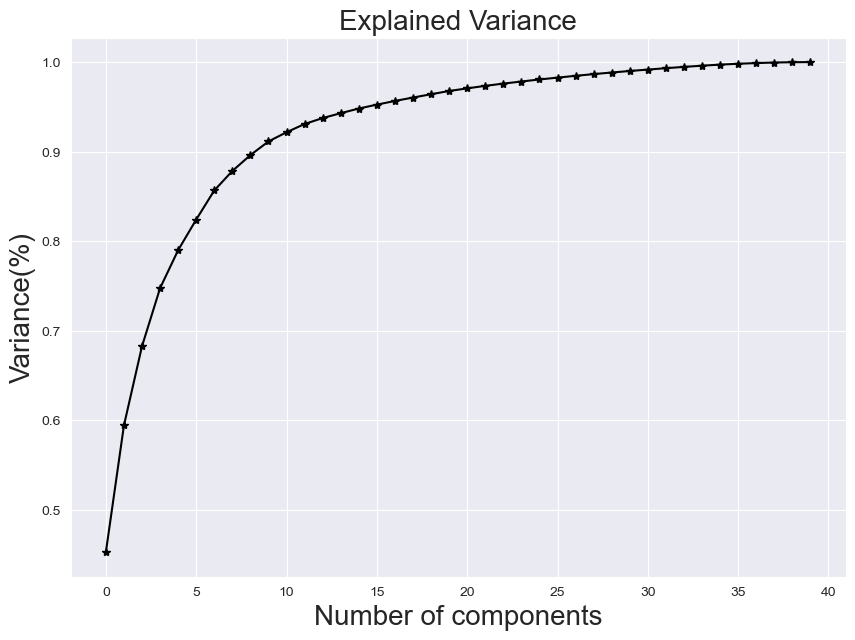

In [58]:
from sklearn.decomposition import PCA
pca = PCA()
principlecomponents = pca.fit_transform(df_numeric)
plt.figure(figsize=(10,7))
sns.set_style('darkgrid')
plt.plot(np.cumsum(pca.explained_variance_ratio_),marker='*',color='k') #plot the variance ratio
plt.xlabel('Number of components',fontsize=20)
plt.ylabel('Variance(%)',fontsize=20)
plt.title('Explained Variance',fontsize=20)
plt.show()

In [59]:
pca = PCA(n_components=10)
fifa = pca.fit_transform(df_numeric)
pca_df = pd.DataFrame(data=fifa,columns=['pca1','pca2','pca3','pca4','pca5','pca6','pca7','pca8','pca9','pca10'])